In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os
import kagglehub



In [2]:

path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
print("Veri seti yolu:", path)


100%|████████████████████████████████████████████████| 157M/157M [00:16<00:00, 9.76MB/s]

Extracting files...


Veri seti yolu: /home/sero/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/2


In [ ]:
# giris cozunurlugu 512x512 olarak ayarlaninca => 0.955625 basari elde edildi
# 

In [2]:
# GIRIS VE DOGRULAMA ICIN BOYUT AYARLAMALARI 
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((512, 512)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((512, 512)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import os

data_dir = "/home/sero/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/2"  

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((512, 512)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((512, 512)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
}

image_datasets = {
    'train': datasets.ImageFolder(os.path.join(data_dir, 'Training'), data_transforms['train']),
    'val':   datasets.ImageFolder(os.path.join(data_dir, 'Testing'),  data_transforms['val']),
}

dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=32, shuffle=True, num_workers=2)
    for x in ['train', 'val']
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names   = image_datasets['train'].classes
device        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {device}")
print(f"Sınıflar: {class_names}")
print(f"Eğitim: {dataset_sizes['train']} | Doğrulama: {dataset_sizes['val']}")

Device: cuda
Sınıflar: ['glioma', 'meningioma', 'notumor', 'pituitary']
Eğitim: 5600 | Doğrulama: 1600


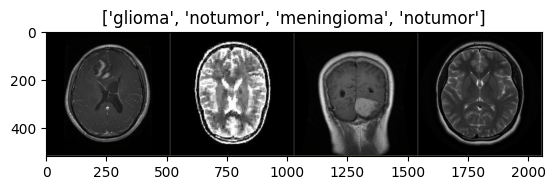

In [5]:
import torchvision
import numpy as np 
import matplotlib.pyplot as plt 
def imshow(inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.show()

inputs, classes = next(iter(dataloaders['train']))
out = torchvision.utils.make_grid(inputs[:4])
imshow(out, title=[class_names[x] for x in classes[:4]])

In [53]:
def initialize_resnet(num_classes):

    model = models.resnet18(weights='IMAGENET1K_V1')

    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)
    return model.to(device)

try:
    model = initialize_resnet(num_classes=len(class_names))
    print("ResNet18 modeli başarıyla yüklendi.")
except NameError:
    print("Hata")

Downloading: "https://download.pytorch.org/models/resnext50_32x4d-7cdf4587.pth" to /home/sero/.cache/torch/hub/checkpoints/resnext50_32x4d-7cdf4587.pth


100%|██████████████████████████████████████████████| 95.8M/95.8M [01:03<00:00, 1.58MB/s]


ResNet18 modeli başarıyla yüklendi.


In [6]:
def train_model(model, criterion, optimizer, num_epochs=10):
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

    return model

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Eğitim için kayıp fonksiyonu ve optimizer hazır.")

NameError: name 'model' is not defined

In [8]:
import time
import copy
import torch

def train_model(model, criterion, optimizer, scheduler, num_epochs=10):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'val':
                scheduler.step(epoch_loss)
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
        print()

    time_elapsed = time.time() - since
    print(f'Eğitim tamamlandı: {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'En iyi doğrulama başarısı: {best_acc:4f}')
    model.load_state_dict(best_model_wts)
    return model

if 'scheduler' not in globals():
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)

model_ft = train_model(model, criterion, optimizer, scheduler, num_epochs=10)

NameError: name 'optimizer' is not defined

Test Doğruluğu: %94.38

Sınıflandırma Raporu:
              precision    recall  f1-score   support

      glioma       0.99      0.81      0.89       400
  meningioma       0.91      0.97      0.94       400
     notumor       0.90      1.00      0.95       400
   pituitary       0.98      1.00      0.99       400

    accuracy                           0.94      1600
   macro avg       0.95      0.94      0.94      1600
weighted avg       0.95      0.94      0.94      1600



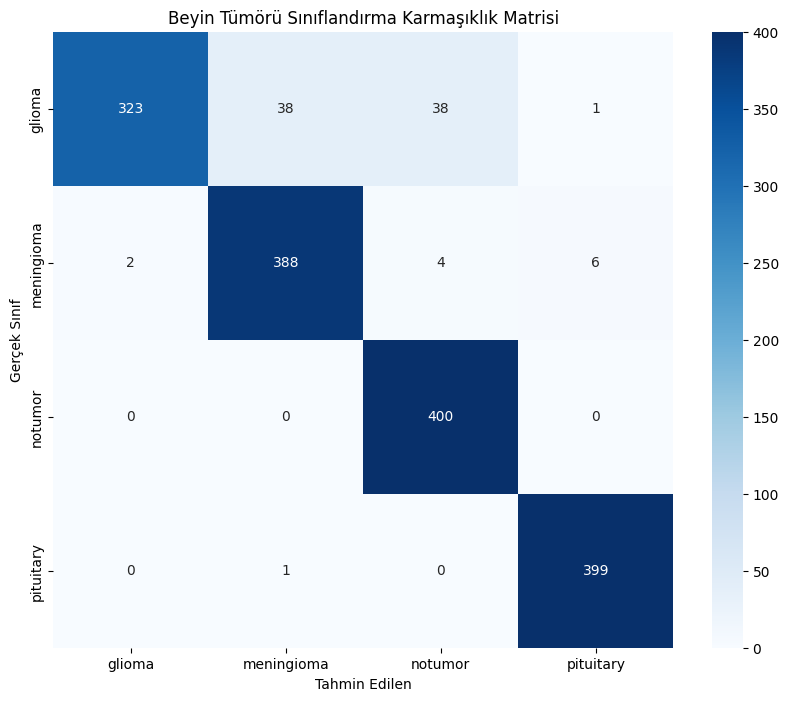

In [35]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import torch

def evaluate_model(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print(f"Test Doğruluğu: %{accuracy_score(all_labels, all_preds)*100:.2f}")
    print("\nSınıflandırma Raporu:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Tahmin Edilen')
    plt.ylabel('Gerçek Sınıf')
    plt.title('Beyin Tümörü Sınıflandırma Karmaşıklık Matrisi')
    plt.show()

# En iyi sonuç veren model ile tekrar değerlendir
evaluate_model(model_ft, dataloaders['val'])

In [ ]:
from PIL import Image
import torch.nn.functional as F
import glob

# elle verilen veri ve test

def predict_image(model, class_names, image_path):

    img = Image.open(image_path).convert('RGB')
    plt.imshow(img)
    plt.title("Girdi Görüntüsü")
    plt.axis('off')
    plt.show()

    img_t = data_transforms['val'](img)
    batch_t = torch.unsqueeze(img_t, 0).to(device)

    model.eval()
    with torch.no_grad():
        out = model(batch_t)
        probabilities = F.softmax(out, dim=1)
        conf, preds = torch.max(probabilities, 1)

    result = class_names[preds[0]]
    confidence = conf[0].item() * 100
    print(f"Tahmin: {result.upper()}")
    print(f"Güven Oranı: %{confidence:.2f}")
for path in glob.glob("/home/sero/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/2/Training/meningioma/*.jpg"):
    print(f"\n--- {os.path.basename(path)} ---")
    predict_image(model_ft, class_names, path)



In [ ]:
import torch

# Modeli kaydetme
model_save_path = 'brain_tumor_resnet18_model2.pth'

# model_ft değişkeninin tanımlı olup olmadığını kontrol et
if 'model_ft' in locals() or 'model_ft' in globals():
    torch.save(model_ft.state_dict(), model_save_path)
    print(f"Model '{model_save_path}' konumuna kaydedildi.")
else:
    print("Hata: 'model_ft' tanımlanmamış. Lütfen modeli eğittiğiniz 1cf00e31 hücresini çalıştırdığınızdan emin olun.")

